In [3]:
import pandas as pd
import numpy as np
import os

def load_scenario_data(scenario_id, base_path=r"D:\LeakDB_full_data\Hanoi"):
    try:
        scenario_path = os.path.join(base_path, f"Scenario-{scenario_id}")
        if not os.path.exists(scenario_path):
            print(f"Scenario {scenario_id} not found.")
            return None
        
        leaks, timestamps = None, None
        demand_path = flow_path = pressure_path = None
        for sub in os.listdir(scenario_path):
            if sub in [f"Scenario-{scenario_id}", f"Scenario-{scenario_id}_info.csv", f"Hanoi_CMH_Scenario-{scenario_id}.inp"]:
                continue
            sub_path = os.path.join(scenario_path, sub)
            if sub == "Demands":
                demand_path = sub_path
            elif sub == "Flows":
                flow_path = sub_path
            elif sub == "Pressures":
                pressure_path = sub_path
            elif sub == "Labels.csv":
                leaks = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")
            elif sub == "Timestamps.csv":
                timestamps = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")

        if not all([demand_path, flow_path, pressure_path, leaks is not None, timestamps is not None]):
            print(f"Scenario {scenario_id} is incomplete.")
            return None

        df = pd.concat([leaks, timestamps], axis=1, ignore_index=True)
        df.columns = ["Leaks", "Timestamps"]

        def combined_feature_df(path, feature):
            dfs = []
            for file in sorted(os.listdir(path)):
                file_path = os.path.join(path, file)
                if not file.endswith(".csv"):
                    continue
                sub_df = pd.read_csv(file_path).drop(columns="Index", errors="ignore")
                sub_df.columns = [f"{feature}_{file.split('.')[0]}"]
                dfs.append(sub_df)
            return pd.concat(dfs, axis=1, ignore_index=True)

        demand_df = combined_feature_df(demand_path, "demand")
        pressure_df = combined_feature_df(pressure_path, "pressure")
        flow_df = combined_feature_df(flow_path, "flow")

        demand_df.columns = [f"demand_node_{i}" for i in range(1, demand_df.shape[1] + 1)]
        pressure_df.columns = [f"pressure_node_{i}" for i in range(1, pressure_df.shape[1] + 1)]
        flow_df.columns = [f"flow_link_{i}" for i in range(1, flow_df.shape[1] + 1)]

        final_df = pd.concat([demand_df, pressure_df, flow_df, df], axis=1)
        final_df["Leaks"] = final_df["Leaks"].astype(int)
        return final_df

    except Exception as e:
        print(f"Error loading scenario {scenario_id}: {e}")
        return None


In [4]:
import matplotlib.pyplot as plt

def visualise_and_analysis(df):
    
    demand_cols = [col for col in df.columns if 'demand' in col]
    pressure_cols = [col for col in df.columns if 'pressure' in col]
    flow_cols = [col for col in df.columns if 'flow' in col]
    
    demand_df = df[demand_cols]
    pressure_df = df[pressure_cols]
    flow_df = df[flow_cols]
    
    print("----Demand, Pressure, Flow plots----\n")
    
    demand_df.plot(figsize=(10, 6))
    plt.title("demand over time")
    plt.xlabel("Time (rows)")
    plt.ylabel("demand (nodes 1 - 32)")
    plt.tight_layout()
    plt.show()
    
    pressure_df.plot(figsize=(10, 6))
    plt.title("pressure over time")
    plt.xlabel("Time (rows)")
    plt.ylabel("pressure (nodes 1 - 32)")
    plt.tight_layout()
    plt.show()
    
    flow_df.plot(figsize=(10, 6))
    plt.title("flow over time")
    plt.xlabel("Time (rows)")
    plt.ylabel("flow (links 1 - 34)")
    plt.tight_layout()
    plt.show()
    
    print("----Demand, Pressure, Flow plots----\n")
    
    print("----Leaks vs no Leaks----\n")
    
    print(df["Leaks"].value_counts())
    
    df["Leaks"].value_counts().hist(bins=20)
    
    print("----Leaks vs no Leaks----\n")

In [5]:
scenario_id = 9

data = load_scenario_data(scenario_id)

data.head(10)

,demand_node_1,demand_node_2,demand_node_3,demand_node_4,demand_node_5,demand_node_6,demand_node_7,demand_node_8,demand_node_9,demand_node_10,...,flow_link_27,flow_link_28,flow_link_29,flow_link_30,flow_link_31,flow_link_32,flow_link_33,flow_link_34,Leaks,Timestamps
0,-3366.0,79.2,93.6,90.0,162.0,93.6,50.4,46.8,158.4,266.4,...,64.8,190.8,1242.0,1123.2,968.4,748.8,651.6,579.6,0,2017-01-01 00:00:00
1,-3027.6,64.8,79.2,79.2,147.6,86.4,43.2,43.2,129.6,255.6,...,54.0,165.6,1108.8,1004.4,860.4,655.2,572.4,507.6,0,2017-01-01 00:30:00
2,-2617.2,61.2,75.6,72.0,126.0,72.0,32.4,39.6,122.4,234.0,...,50.4,136.8,946.8,860.4,748.8,576.0,507.6,453.6,0,2017-01-01 01:00:00
3,-2394.0,50.4,61.2,64.8,122.4,64.8,32.4,32.4,122.4,237.6,...,46.8,136.8,874.8,795.6,691.2,525.6,460.8,410.4,0,2017-01-01 01:30:00
4,-2246.4,50.4,61.2,61.2,111.6,61.2,32.4,28.8,111.6,212.4,...,43.2,115.2,828.0,745.2,648.0,493.2,432.0,385.2,0,2017-01-01 02:00:00
5,-2127.6,46.8,57.6,57.6,100.8,64.8,28.8,28.8,97.2,208.8,...,46.8,115.2,781.2,698.4,612.0,468.0,410.4,367.2,0,2017-01-01 02:30:00
6,-2167.2,50.4,64.8,61.2,100.8,64.8,32.4,32.4,108.0,183.6,...,46.8,122.4,799.2,727.2,644.4,482.4,421.2,378.0,0,2017-01-01 03:00:00
7,-2300.4,54.0,68.4,61.2,104.4,68.4,36.0,32.4,104.4,205.2,...,43.2,115.2,853.2,766.8,673.2,500.4,439.2,396.0,0,2017-01-01 03:30:00
8,-2520.0,57.6,68.4,57.6,122.4,68.4,36.0,36.0,133.2,244.8,...,46.8,133.2,910.8,820.8,712.8,540.0,475.2,421.2,0,2017-01-01 04:00:00
9,-2754.0,64.8,68.4,68.4,144.0,86.4,43.2,36.0,118.8,226.8,...,50.4,154.8,1011.6,914.4,799.2,612.0,540.0,471.6,0,2017-01-01 04:30:00


----Demand, Pressure, Flow plots----



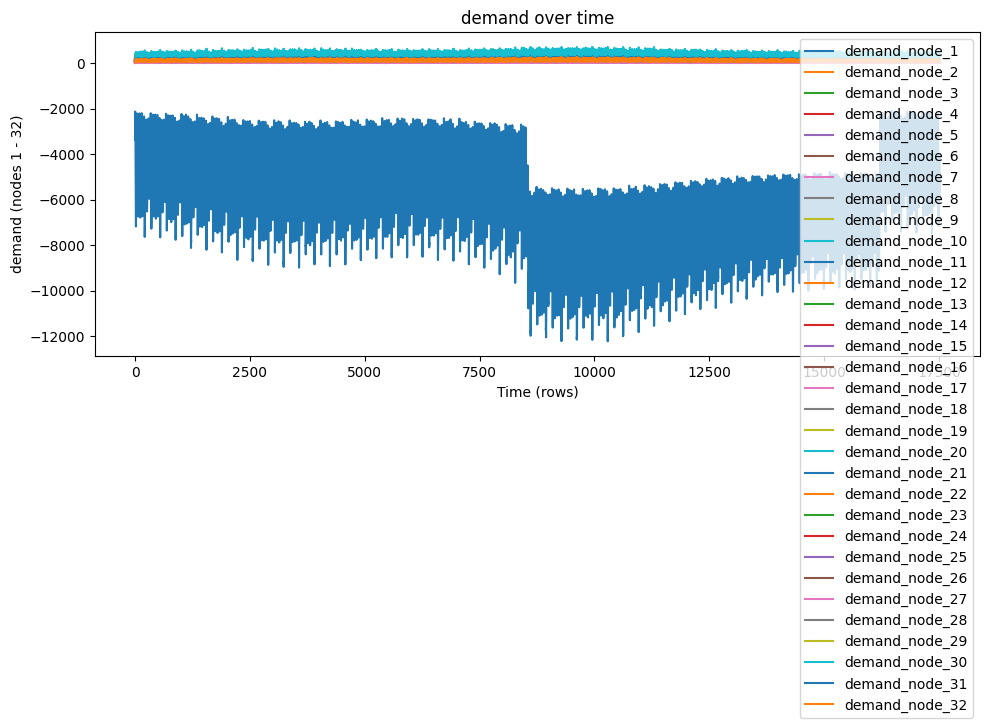

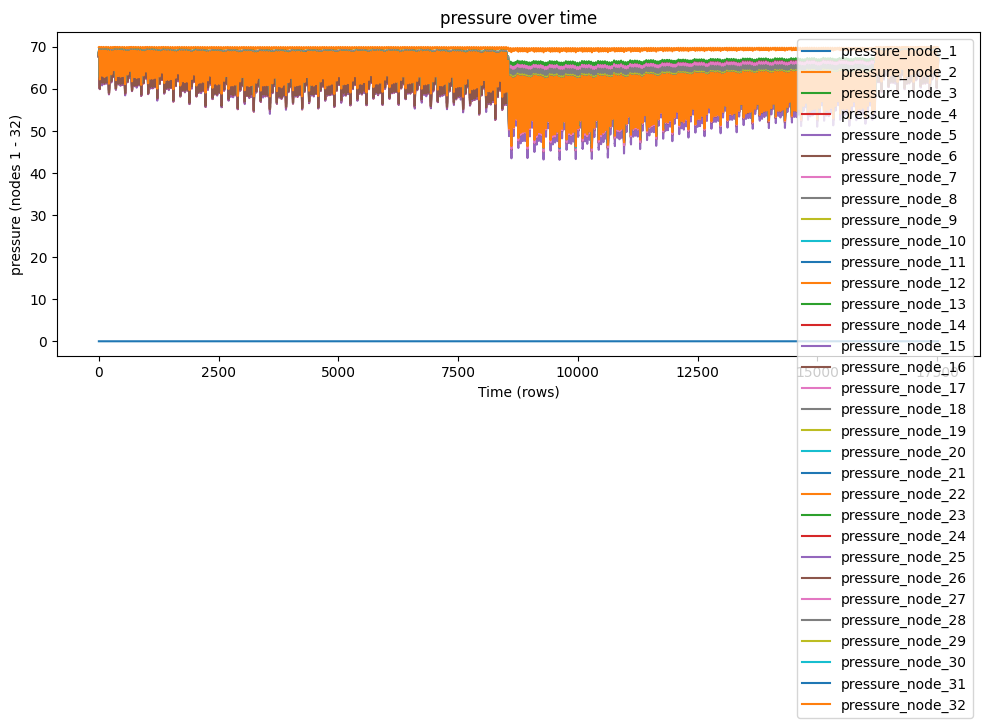

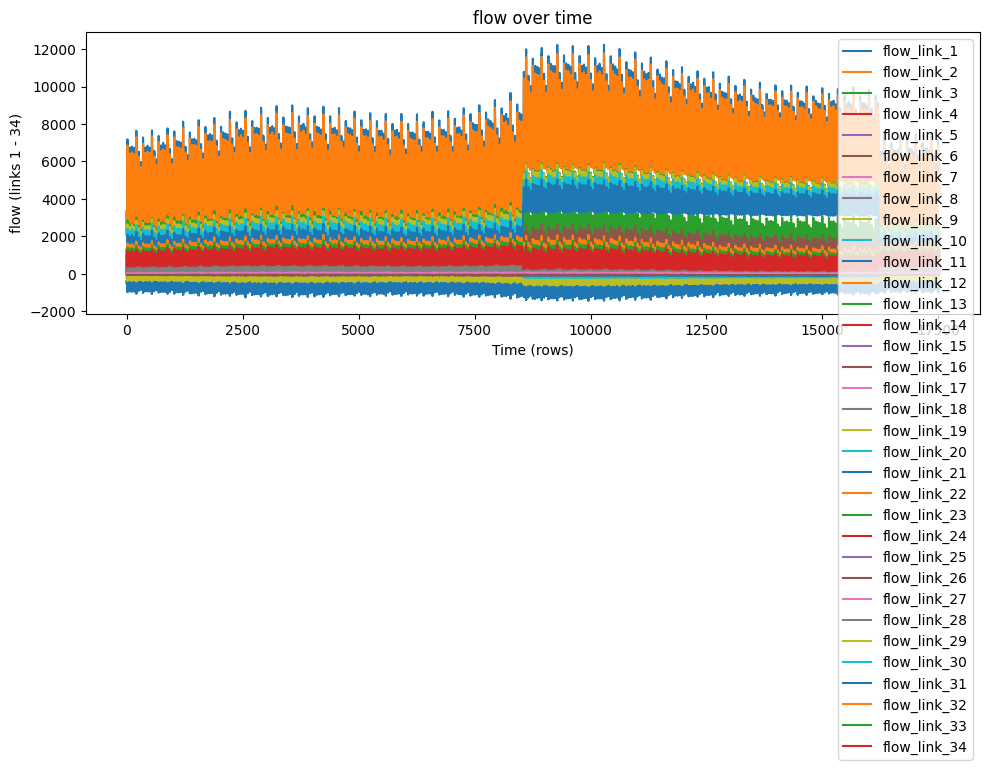

----Demand, Pressure, Flow plots----

----Leaks vs no Leaks----

Leaks
0    9857
1    7663
Name: count, dtype: int64
----Leaks vs no Leaks----



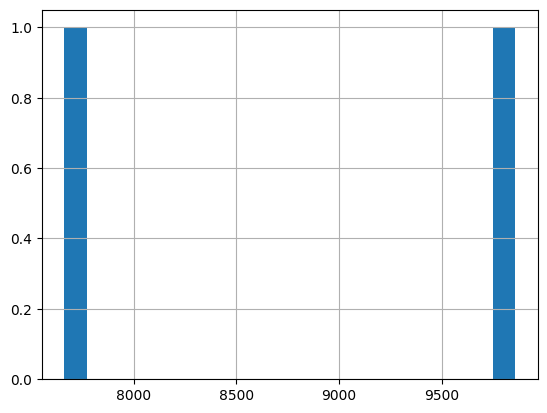

In [6]:
visualise_and_analysis(data)

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader

import os
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")




Using device: cuda


In [8]:
import numpy as np

RANDOM_SEED = 123
WIDNOW_SIZE = 12 # 6 hours
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001
PATIENCE = 25
TRAIN_TEST_SPLIT = 0.85

np.random.seed(123)
torch.manual_seed(RANDOM_SEED)

if device.type == "cuda":
    torch.cuda.manual_seed(RANDOM_SEED)


In [9]:
def create_sliding_window(df, window_size=WIDNOW_SIZE):
    
    feature_cols = [col for col in df if col not in ['Leaks', 'Timestamps']]
    
    features = df[feature_cols].values
    targets = df['Leaks'].values
    
    X_sequences = []
    Y_sequences = []
    
    for i in range(len(features) - window_size):
        
        X_seq = features[i:i+window_size]
        Y_seq = targets[i + window_size]
        
        X_sequences.append(X_seq)
        Y_sequences.append(Y_seq)
        
    return np.array(X_sequences), np.array(Y_sequences)

In [10]:
class TimeSeriesLeakDetectionModel(nn.Module):
    
    def __init__(self, input_dim, hidden_dim=128, num_layers=2):
        super(TimeSeriesLeakDetectionModel, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        
        lstm_out, (hidden, cell) = self.lstm(x)
        
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        hidden_combined = torch.cat((hidden_forward, hidden_backward), dim=1)
        
        x = self.dropout(hidden_combined)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        
        output = self.sigmoid(self.output(x))
        return output

In [11]:
print(f"Scenario loaded: {len(data)} timestamps.")
print(f"Leak statistics: {data['Leaks'].sum()} leaks out of {len(data)} timestamps ({data['Leaks'].mean()*100:.2f}%)")

X_sequences, Y_sequences = create_sliding_window(data)

print(f"Created sequences: {X_sequences.shape}")
print(f"Leak sequences: {Y_sequences.sum()} out of {len(Y_sequences)} ({Y_sequences.mean()*100:.2f}%)")


Scenario loaded: 17520 timestamps.
Leak statistics: 7663 leaks out of 17520 timestamps (43.74%)
Created sequences: (17508, 12, 98)
Leak sequences: 7663 out of 17508 (43.77%)


In [12]:
split_index = int(len(X_sequences) * TRAIN_TEST_SPLIT)
X_train = X_sequences[:split_index]
Y_train = Y_sequences[:split_index]
X_test = X_sequences[split_index:]
Y_test = Y_sequences[split_index:]

In [13]:
print(f"\nTrain set: {X_train.shape[0]} sequences")
print(f"Test set: {X_test.shape[0]} sequences")
print(f"Train leaks: {Y_train.sum()} ({Y_train.mean()*100:.2f}%)")
print(f"Test leaks: {Y_test.sum()} ({Y_test.mean()*100:.2f}%)")


Train set: 14881 sequences
Test set: 2627 sequences
Train leaks: 6348 (42.66%)
Test leaks: 1315 (50.06%)


In [14]:
scaler = StandardScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_train = X_train_scaled.reshape(X_train.shape)

X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_reshaped)
X_test = X_test_scaled.reshape(X_test.shape)

In [15]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(Y_train),
    y=Y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

In [16]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).to(device)

In [17]:
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

In [18]:
input_dim = X_train.shape[2]
input_dim

98

In [19]:
model = TimeSeriesLeakDetectionModel(input_dim=input_dim).to(device)

In [20]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)

In [21]:
print(f"\nTime Series Leak Detection Model:")
print(f"Input dimension: {input_dim}")
print(f"Training on Scenario {scenario_id}")


Time Series Leak Detection Model:
Input dimension: 98
Training on Scenario 9


In [22]:
print(f"\nStarting Training...")
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        x, y = [b.to(device) for b in batch]
        
        optimizer.zero_grad()
        predictions = model(x)
        
        loss = criterion(predictions.squeeze(), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * x.size(0)
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    test_loss = 0.0
    test_preds, test_true = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            x, y = [b.to(device) for b in batch]
            predictions = model(x)
            
            loss = criterion(predictions.squeeze(), y)
            test_loss += loss.item() * x.size(0)
            
            test_preds.append(predictions.cpu().numpy())
            test_true.append(y.cpu().numpy())
    
    test_loss /= len(test_dataset)
    val_losses.append(test_loss)
    
    test_preds = np.concatenate(test_preds).flatten()
    test_true = np.concatenate(test_true)
    test_acc = accuracy_score(test_true, (test_preds > 0.5).astype(int))
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    if test_loss < best_val_loss:
        best_val_loss = test_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print("Early stopping triggered")
        break
    
    scheduler.step(test_loss)

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("\nTraining completed!")


Starting Training...
Epoch 1/100, Train Loss: 0.0286, Test Loss: 0.0135, Test Acc: 0.9973
Epoch 2/100, Train Loss: 0.0026, Test Loss: 0.0111, Test Acc: 0.9981
Epoch 3/100, Train Loss: 0.0026, Test Loss: 0.0092, Test Acc: 0.9985
Epoch 4/100, Train Loss: 0.0030, Test Loss: 0.0107, Test Acc: 0.9981
Epoch 5/100, Train Loss: 0.0028, Test Loss: 0.0138, Test Acc: 0.9985
Epoch 6/100, Train Loss: 0.0033, Test Loss: 0.0077, Test Acc: 0.9989
Epoch 7/100, Train Loss: 0.0023, Test Loss: 0.0096, Test Acc: 0.9985
Epoch 8/100, Train Loss: 0.0028, Test Loss: 0.0086, Test Acc: 0.9989
Epoch 9/100, Train Loss: 0.0040, Test Loss: 0.0072, Test Acc: 0.9989
Epoch 10/100, Train Loss: 0.0026, Test Loss: 0.0080, Test Acc: 0.9985
Epoch 11/100, Train Loss: 0.0030, Test Loss: 0.0077, Test Acc: 0.9985
Epoch 12/100, Train Loss: 0.0029, Test Loss: 0.0103, Test Acc: 0.9989
Epoch 13/100, Train Loss: 0.0027, Test Loss: 0.0082, Test Acc: 0.9985
Epoch 14/100, Train Loss: 0.0028, Test Loss: 0.0055, Test Acc: 0.9992
Epoch 1

In [23]:
print(f"\n{'='*60}")
print(f"FINAL EVALUATION - SCENARIO {scenario_id}")
print(f"{'='*60}")

model.eval()
all_preds, all_true, all_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        x, y = [b.to(device) for b in batch]
        pred = model(x)
        all_preds.append(pred.cpu().numpy())
        all_true.append(y.cpu().numpy())

all_probs = np.concatenate(all_preds).flatten()
all_true = np.concatenate(all_true)
all_pred_binary = (all_probs > 0.5).astype(int)


FINAL EVALUATION - SCENARIO 9


In [24]:
accuracy = accuracy_score(all_true, all_pred_binary)
precision = precision_score(all_true, all_pred_binary, zero_division=0)
recall = recall_score(all_true, all_pred_binary, zero_division=0)
f1 = f1_score(all_true, all_pred_binary, zero_division=0)
conf_matrix = confusion_matrix(all_true, all_pred_binary)

In [25]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"\nConfusion Matrix:")
print(conf_matrix)
print(f"\nClassification Report:")
print(classification_report(all_true, all_pred_binary, target_names=['No Leak', 'Leak']))

Accuracy: 0.9989
Precision: 0.9977
Recall: 1.0000
F1-Score: 0.9989

Confusion Matrix:
[[1306    3]
 [   0 1315]]

Classification Report:
              precision    recall  f1-score   support

     No Leak       1.00      1.00      1.00      1309
        Leak       1.00      1.00      1.00      1315

    accuracy                           1.00      2624
   macro avg       1.00      1.00      1.00      2624
weighted avg       1.00      1.00      1.00      2624



In [26]:
print(f"\n{'='*60}")
print(f"DETAILED ANALYSIS")
print(f"{'='*60}")
print(f"Total test samples: {len(all_true)}")
print(f"Actual leaks in test set: {all_true.sum()} ({all_true.mean()*100:.2f}%)")
print(f"Predicted leaks: {all_pred_binary.sum()} ({all_pred_binary.mean()*100:.2f}%)")

if all_true.sum() > 0:
    leak_indices = all_true == 1
    leak_accuracy = accuracy_score(all_true[leak_indices], all_pred_binary[leak_indices])
    print(f"Leak-only accuracy: {leak_accuracy:.4f}")


DETAILED ANALYSIS
Total test samples: 2624
Actual leaks in test set: 1315.0 (50.11%)
Predicted leaks: 1318 (50.23%)
Leak-only accuracy: 1.0000


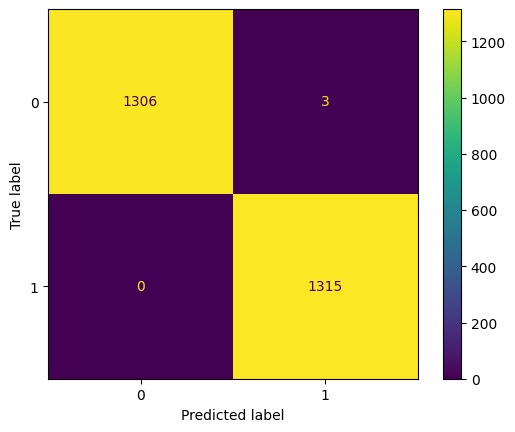

In [27]:
disp = ConfusionMatrixDisplay(confusion_matrix(all_true, all_pred_binary))
disp.plot()
plt.show()

In [28]:
def test_on_new_scenario(model, scaler, new_scenario_id, base_path=r"D:\LeakDB_full_data\Hanoi"):
    print(f"\n{'='*80}")
    print(f"TESTING ON NEW SCENARIO {new_scenario_id}")
    print(f"{'='*80}")
    
    new_scenario_df = load_scenario_data(new_scenario_id, base_path)
    if new_scenario_df is None:
        print(f"Failed to load scenario {new_scenario_id}")
        return None
    
    print(f"New scenario loaded: {len(new_scenario_df)} timestamps")
    print(f"Leak statistics: {new_scenario_df['Leaks'].sum()} leaks out of {len(new_scenario_df)} timestamps ({new_scenario_df['Leaks'].mean()*100:.2f}%)")
    
    X_new, y_new = create_sliding_window(new_scenario_df)
    
    print(f"Created sequences: {X_new.shape}")
    print(f"Leak sequences: {y_new.sum()} out of {len(y_new)} ({y_new.mean()*100:.2f}%)")
    
    X_new_reshaped = X_new.reshape(-1, X_new.shape[-1])
    X_new_scaled = scaler.transform(X_new_reshaped)
    X_new = X_new_scaled.reshape(X_new.shape)

    X_new_tensor = torch.tensor(X_new, dtype=torch.float32).to(device)
    y_new_tensor = torch.tensor(y_new, dtype=torch.float32).to(device)

    new_dataset = TensorDataset(X_new_tensor, y_new_tensor)
    new_loader = DataLoader(new_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model.eval()
    all_preds, all_true, all_probs = [], [], []
    
    with torch.no_grad():
        for batch in new_loader:
            x, y = [b.to(device) for b in batch]
            pred = model(x)
            all_preds.append(pred.cpu().numpy())
            all_true.append(y.cpu().numpy())
    
    all_probs = np.concatenate(all_preds).flatten()
    all_true = np.concatenate(all_true)
    all_pred_binary = (all_probs > 0.5).astype(int)
   
    accuracy = accuracy_score(all_true, all_pred_binary)
    precision = precision_score(all_true, all_pred_binary, zero_division=0)
    recall = recall_score(all_true, all_pred_binary, zero_division=0)
    f1 = f1_score(all_true, all_pred_binary, zero_division=0)
    conf_matrix = confusion_matrix(all_true, all_pred_binary)
    
    total_samples = len(all_true)
    actual_leaks = all_true.sum()
    predicted_leaks = all_pred_binary.sum()
    correct_predictions = (all_pred_binary == all_true).sum()
    
    leak_indices = all_true == 1
    no_leak_indices = all_true == 0
    
    leak_accuracy = accuracy_score(all_true[leak_indices], all_pred_binary[leak_indices]) if leak_indices.sum() > 0 else 0
    no_leak_accuracy = accuracy_score(all_true[no_leak_indices], all_pred_binary[no_leak_indices]) if no_leak_indices.sum() > 0 else 0

    results = {
        'scenario_id': new_scenario_id,
        'total_samples': total_samples,
        'actual_leaks': int(actual_leaks),
        'predicted_leaks': int(predicted_leaks),
        'correct_predictions': int(correct_predictions),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': conf_matrix,
        'leak_accuracy': leak_accuracy,
        'no_leak_accuracy': no_leak_accuracy,
        'leak_percentage': (actual_leaks / total_samples) * 100,
        'predictions': all_pred_binary,
        'probabilities': all_probs,
        'true_labels': all_true
    }

    print(f"\n{'='*60}")
    print(f"RESULTS FOR SCENARIO {new_scenario_id}")
    print(f"{'='*60}")
    print(f"Total sequences: {total_samples}")
    print(f"Actual leaks: {actual_leaks} ({results['leak_percentage']:.2f}%)")
    print(f"Predicted leaks: {predicted_leaks} ({(predicted_leaks/total_samples)*100:.2f}%)")
    print(f"Correct predictions: {correct_predictions} ({(correct_predictions/total_samples)*100:.2f}%)")
    print(f"\nMetrics:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    if actual_leaks > 0:
        print(f"Leak Detection Accuracy: {leak_accuracy:.4f}")
    if no_leak_indices.sum() > 0:
        print(f"No-Leak Accuracy: {no_leak_accuracy:.4f}")
    
    print(f"\nConfusion Matrix:")
    print(conf_matrix)
    print(f"\nClassification Report:")
    print(classification_report(all_true, all_pred_binary, target_names=['No Leak', 'Leak']))
    
    if actual_leaks > 0:
        plot_predictions_vs_actual(results, new_scenario_id)
    
    return results

def plot_predictions_vs_actual(results, scenario_id):
    try:
        import matplotlib.pyplot as plt
        
        plt.figure(figsize=(15, 6))
        
        actual_leak_indices = np.where(results['true_labels'] == 1)[0]
        plt.scatter(actual_leak_indices, [1] * len(actual_leak_indices), 
                   color='red', marker='o', label='Actual Leaks', alpha=0.7, s=50)

        predicted_leak_indices = np.where(results['predictions'] == 1)[0]
        plt.scatter(predicted_leak_indices, [0.5] * len(predicted_leak_indices), 
                   color='blue', marker='x', label='Predicted Leaks', alpha=0.7, s=50)

        plt.plot(results['probabilities'], color='green', alpha=0.5, label='Leak Probability')
        plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.3, label='Decision Threshold (0.5)')
        
        plt.title(f'Leak Detection Results - Scenario {scenario_id}')
        plt.xlabel('Sequence Index')
        plt.ylabel('Leak Probability / Detection')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.1, 1.1)
        plt.tight_layout()
        plt.show()
        
    except ImportError:
        print("Matplotlib not available for plotting")


TESTING ON NEW SCENARIO 24
New scenario loaded: 17520 timestamps
Leak statistics: 9897 leaks out of 17520 timestamps (56.49%)
Created sequences: (17508, 12, 98)
Leak sequences: 9897 out of 17508 (56.53%)

RESULTS FOR SCENARIO 24
Total sequences: 17508
Actual leaks: 9897.0 (56.53%)
Predicted leaks: 400 (2.28%)
Correct predictions: 8011 (45.76%)

Metrics:
Accuracy:  0.4576
Precision: 1.0000
Recall:    0.0404
F1-Score:  0.0777
Leak Detection Accuracy: 0.0404
No-Leak Accuracy: 1.0000

Confusion Matrix:
[[7611    0]
 [9497  400]]

Classification Report:
              precision    recall  f1-score   support

     No Leak       0.44      1.00      0.62      7611
        Leak       1.00      0.04      0.08      9897

    accuracy                           0.46     17508
   macro avg       0.72      0.52      0.35     17508
weighted avg       0.76      0.46      0.31     17508



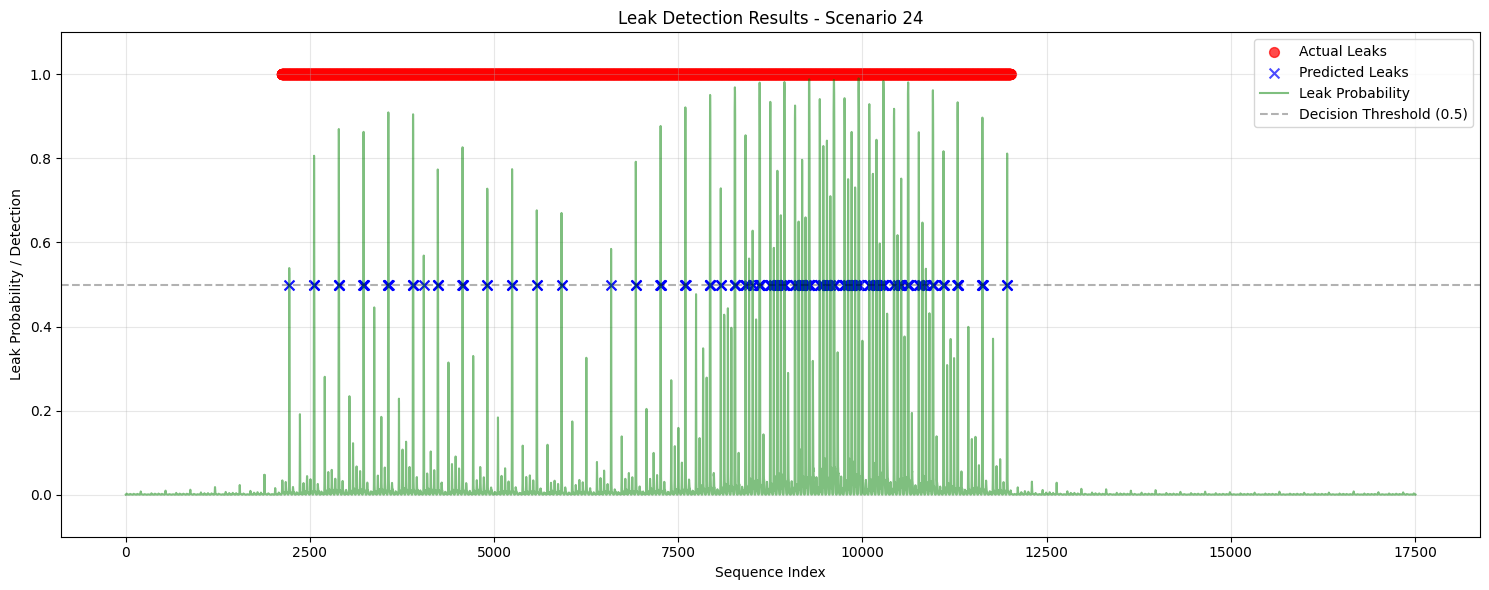

In [29]:
result = test_on_new_scenario(model, scaler, 24)


TESTING ON NEW SCENARIO 89
New scenario loaded: 17520 timestamps
Leak statistics: 2237 leaks out of 17520 timestamps (12.77%)
Created sequences: (17508, 12, 98)
Leak sequences: 2237 out of 17508 (12.78%)

RESULTS FOR SCENARIO 89
Total sequences: 17508
Actual leaks: 2237.0 (12.78%)
Predicted leaks: 30 (0.17%)
Correct predictions: 15241 (87.05%)

Metrics:
Accuracy:  0.8705
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
Leak Detection Accuracy: 0.0000
No-Leak Accuracy: 0.9980

Confusion Matrix:
[[15241    30]
 [ 2237     0]]

Classification Report:
              precision    recall  f1-score   support

     No Leak       0.87      1.00      0.93     15271
        Leak       0.00      0.00      0.00      2237

    accuracy                           0.87     17508
   macro avg       0.44      0.50      0.47     17508
weighted avg       0.76      0.87      0.81     17508



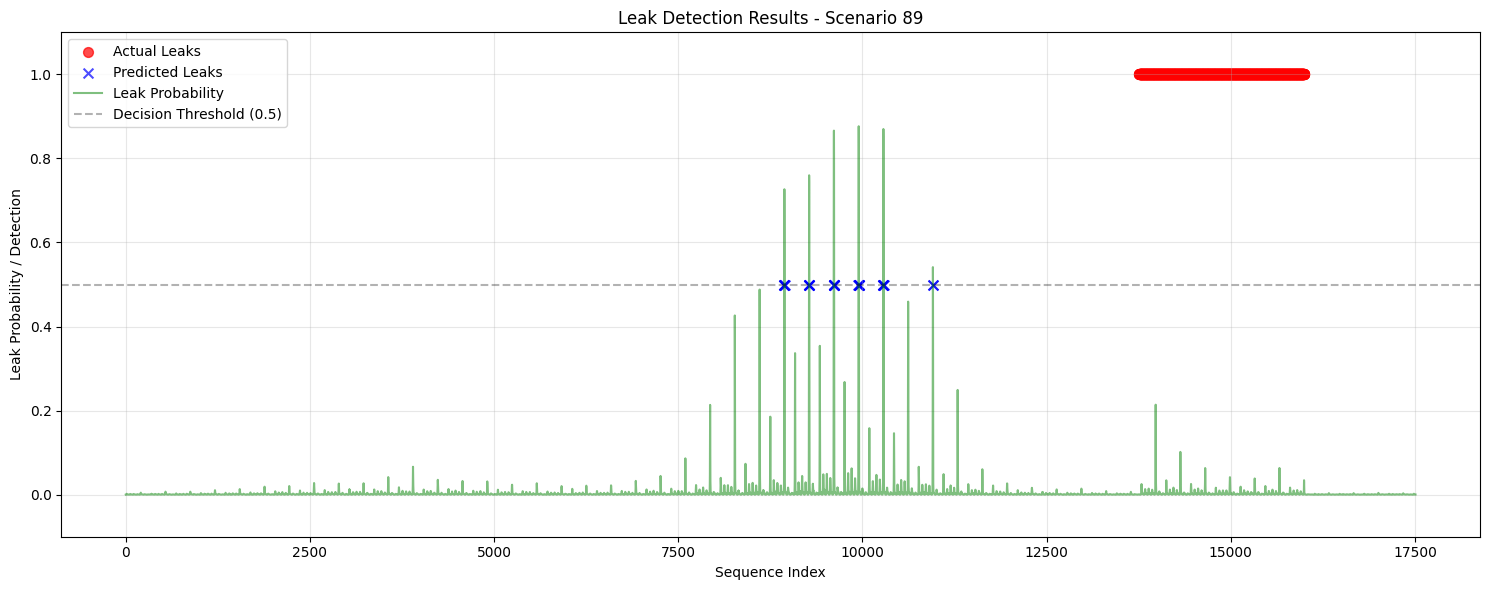

{'scenario_id': 89,
 'total_samples': 17508,
 'actual_leaks': 2237,
 'predicted_leaks': 30,
 'correct_predictions': 15241,
 'accuracy': 0.8705163353895362,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0,
 'confusion_matrix': array([[15241,    30],
        [ 2237,     0]], dtype=int64),
 'leak_accuracy': 0.0,
 'no_leak_accuracy': 0.9980354921092266,
 'leak_percentage': 12.777016221156043,
 'predictions': array([0, 0, 0, ..., 0, 0, 0]),
 'probabilities': array([0.00017832, 0.00020221, 0.00022372, ..., 0.00061557, 0.00052365,
        0.00045985], dtype=float32),
 'true_labels': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)}

In [30]:
test_on_new_scenario(model, scaler, 89)


TESTING ON NEW SCENARIO 200
New scenario loaded: 17520 timestamps
Leak statistics: 965 leaks out of 17520 timestamps (5.51%)
Created sequences: (17508, 12, 98)
Leak sequences: 965 out of 17508 (5.51%)

RESULTS FOR SCENARIO 200
Total sequences: 17508
Actual leaks: 965.0 (5.51%)
Predicted leaks: 0 (0.00%)
Correct predictions: 16543 (94.49%)

Metrics:
Accuracy:  0.9449
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
Leak Detection Accuracy: 0.0000
No-Leak Accuracy: 1.0000

Confusion Matrix:
[[16543     0]
 [  965     0]]

Classification Report:
              precision    recall  f1-score   support

     No Leak       0.94      1.00      0.97     16543
        Leak       0.00      0.00      0.00       965

    accuracy                           0.94     17508
   macro avg       0.47      0.50      0.49     17508
weighted avg       0.89      0.94      0.92     17508



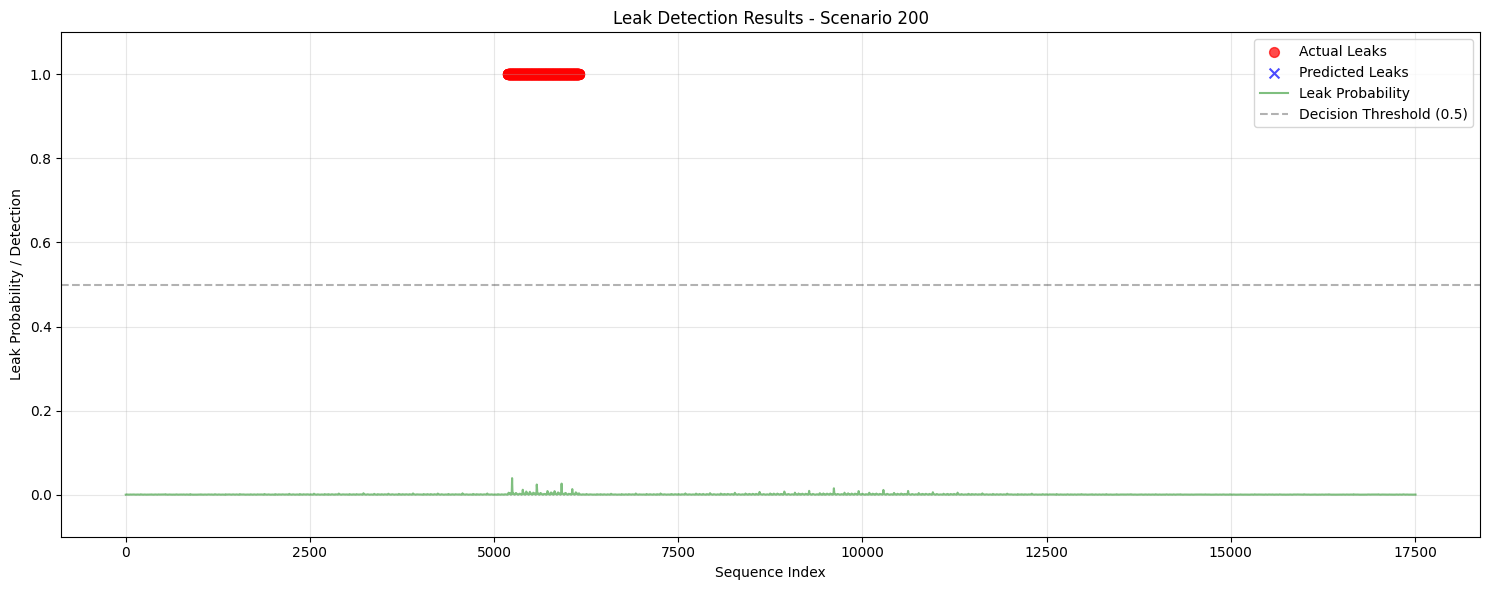

In [31]:
result = test_on_new_scenario(model, scaler, 200)


TESTING ON NEW SCENARIO 11
New scenario loaded: 17520 timestamps
Leak statistics: 1377 leaks out of 17520 timestamps (7.86%)
Created sequences: (17508, 12, 98)
Leak sequences: 1377 out of 17508 (7.86%)

RESULTS FOR SCENARIO 11
Total sequences: 17508
Actual leaks: 1377.0 (7.86%)
Predicted leaks: 0 (0.00%)
Correct predictions: 16131 (92.14%)

Metrics:
Accuracy:  0.9214
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
Leak Detection Accuracy: 0.0000
No-Leak Accuracy: 1.0000

Confusion Matrix:
[[16131     0]
 [ 1377     0]]

Classification Report:
              precision    recall  f1-score   support

     No Leak       0.92      1.00      0.96     16131
        Leak       0.00      0.00      0.00      1377

    accuracy                           0.92     17508
   macro avg       0.46      0.50      0.48     17508
weighted avg       0.85      0.92      0.88     17508



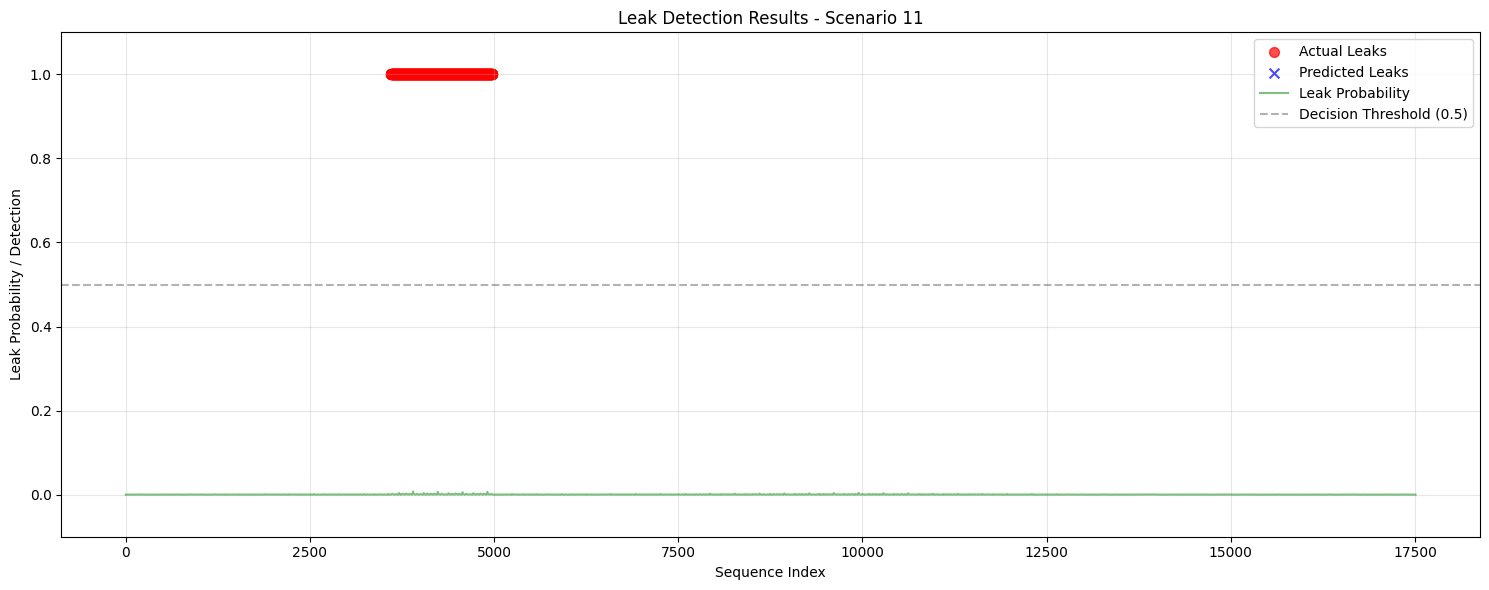

In [32]:
result = test_on_new_scenario(model, scaler, 11)